## Adult Income Classification Project

**Objective:**
Predict whether a person's annual income exceeds $50,000 
using U.S. Census data from 1994.

**Dataset**
- Source: UCI Machine Learning Repository
- Size: 48,842 rows, 15 features
- Target variable: income (<=50K or >50K)

**Approach**
- Phase 1: Data cleaning and exploratory analysis
- Phase 2: Encoding, modeling, and evaluation

**Tools Used**
- pandas, numpy — data manipulation
- matplotlib, seaborn — visualization
- scikit-learn — machine learning

## Phase 1: Data Loading Cleaning & Exploration

### 1.1 Importing Required Libraries

In [152]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split   # split data into train/test sets
from sklearn.preprocessing import LabelEncoder, StandardScaler  # encode categories, scale numbers
from sklearn.linear_model import LogisticRegression     # a simple, solid classification model
from sklearn.tree import DecisionTreeClassifier          # another common classifier
from sklearn.ensemble import RandomForestClassifier      # usually performs better than single trees
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # evaluate predictions


In [153]:
# Global chart styling
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

### 1.2 Loading the Data

In [154]:
# we provide headers to the columns, since the dataset doesn't have any
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
           'marital-status', 'occupation', 'relationship', 'race', 'sex',
           'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

# we load the dataset into a pandas dataframe
df_data = pd.read_csv('adult.data', names=columns, na_values='?', skipinitialspace=True)

df_test = pd.read_csv('adult.test', names=columns, na_values='?', 
                       skipinitialspace=True, skiprows=1)
 #fixing the trailing periood in adult.test's income column
df_test['income']= df_test['income'].str.rstrip('.')

# conect both datasets into a single dataframe for analysis
df= pd.concat([df_data,df_test], ignore_index= True)

# output insights 
print('df_data shape:', df_data.shape)
print('df_test shape:', df_test.shape)
print('combined datasets shape:', df.shape)
print()
print('The incom values should be in two categories, no trailing peridos')
print(df['income'].unique())


df_data shape: (32561, 15)
df_test shape: (16281, 15)
combined datasets shape: (48842, 15)

The incom values should be in two categories, no trailing peridos
['<=50K' '>50K']


### 1.3 Data Inspection and Exploration

In [155]:
print(" frist 5 rows of the dataset:")
df.head()

 frist 5 rows of the dataset:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [156]:
print(df.describe())

                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  48842.000000  4.884200e+04   48842.000000  48842.000000  48842.000000   
mean      38.643585  1.896641e+05      10.078089   1079.067626     87.502314   
std       13.710510  1.056040e+05       2.570973   7452.019058    403.004552   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.175505e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.781445e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.376420e+05      12.000000      0.000000      0.000000   
max       90.000000  1.490400e+06      16.000000  99999.000000   4356.000000   

       hours-per-week  
count    48842.000000  
mean        40.422382  
std         12.391444  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


In [157]:
# The dataset contains 6 numerical columns, 9 categorical columns,
#  and one categorical target column. 
print (" summary statistics of the dataset:")
df.info()


 summary statistics of the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      46033 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  47985 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [158]:
# Count the total number of missing values
print(df.isnull().sum().sum())

# The shape of the dataset
print("The shape of the dataset is:", df.shape)


6465
The shape of the dataset is: (48842, 15)


#### Descriptive Statistics of Numerical Features 

- **Age:** ranges 17–90, mean **38.6 years** — realistic 
  working-age population, no data issues
- **fnlwgt:** census sampling weight
- **education-num:** ranges 1–16, mean **~10** (some college) 
  — kept over text `education` column, already numeric
- **capital-gain/loss:** median **$0** for both — 75% of people 
  report zero, but having ANY gain/loss strongly predicts 
  `>50K` income (61.7% vs 20.5%)
- **hours-per-week:** median **40 hours** (standard work week), 
  range 1–99 — higher earners tend to work slightly more hours

> **Key Takeaway:** despite mostly zero values, `capital-gain` 
> and `capital-loss` are among the **strongest predictors** 
> in the dataset — a reminder that a "boring" distribution 
> does not mean a useless feature.

### 1.4 Handling Missing Values

In [159]:
# let's fix the missing values by filling it with unique value "Unknown" for categorical columns 
# and the median for numerical columns
for col in ['workclass', 'occupation', 'native-country']:
    df[col] = df[col].fillna('Unknown')
df.head()
print(df['occupation'].value_counts())

occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
Unknown              2809
Transport-moving     2355
Handlers-cleaners    2072
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64


### 1.5 Exploratory Data Analysis (EDA)
 Discriptive Statistics of the dataset ( The Numerical Columns)


### 1.5.1 Visualization of Numerical Features

In [160]:
df.info() # exploratory data analysis

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


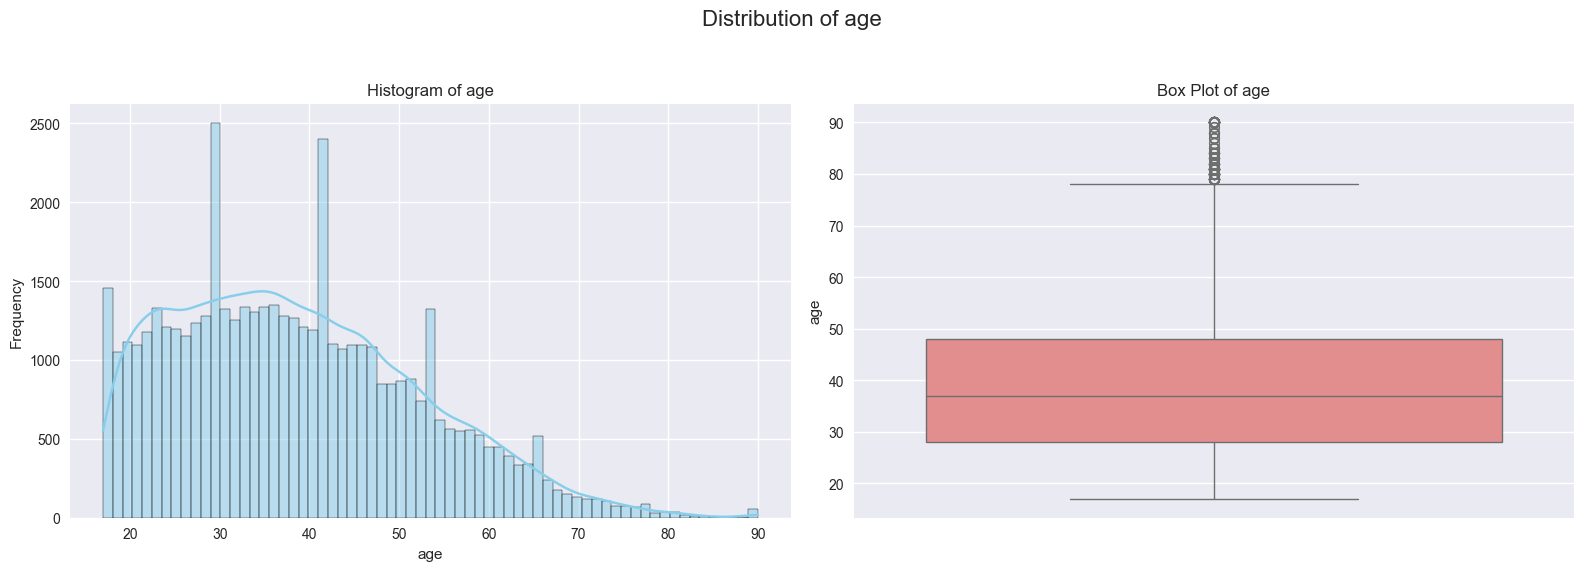

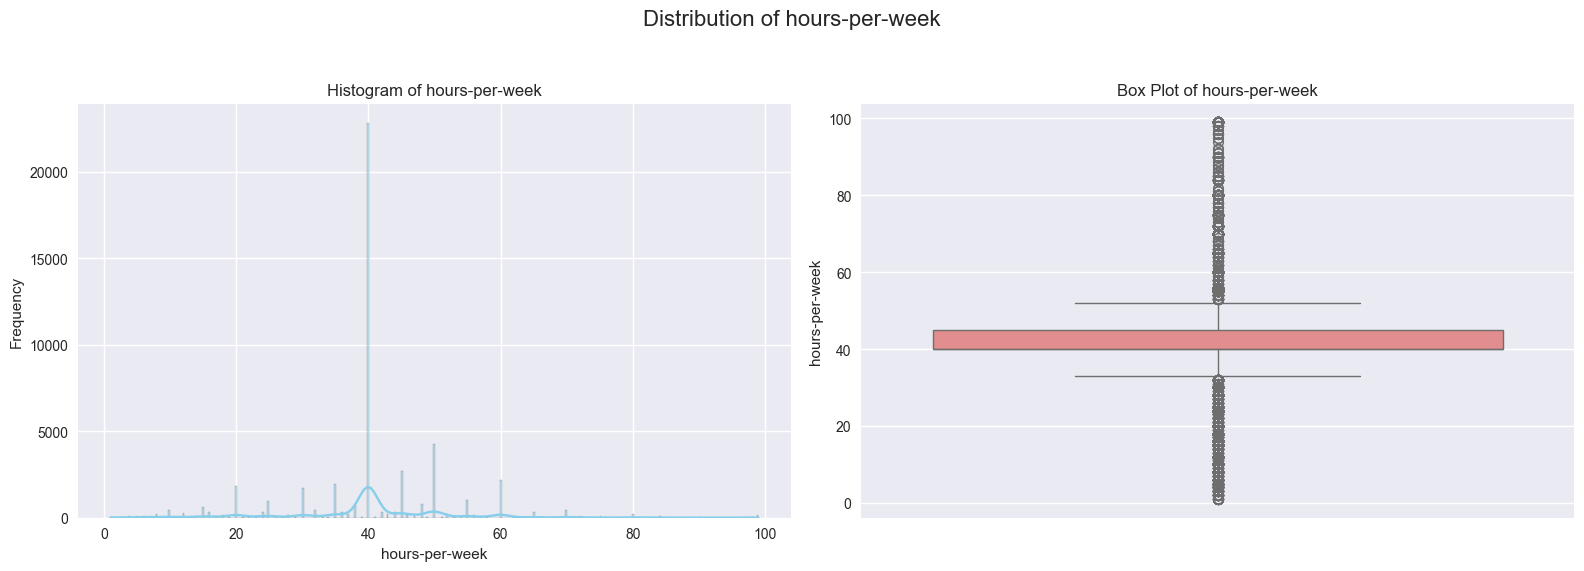

In [161]:
# we define the numaric featurs to visulize 
numerical_features = ['age', 'hours-per-week']
for feature in numerical_features:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Distribution of {feature}', fontsize=16)

    # Histogram with KDE to show distribution and density
    sns.histplot(df[feature], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Histogram of {feature}')
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel('Frequency')

    # Box plot to show spread, median, and outliers
    sns.boxplot(y=df[feature], ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Box Plot of {feature}')
    axes[1].set_ylabel(feature)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

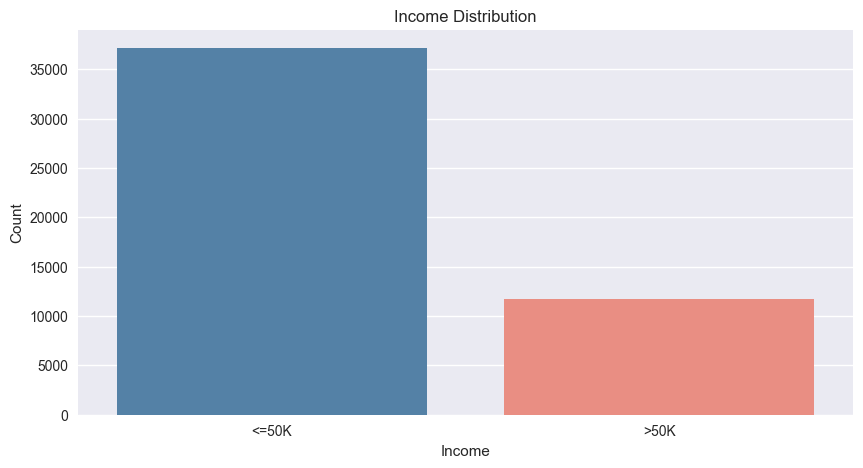

income
<=50K    0.7607
>50K     0.2393
Name: proportion, dtype: float64


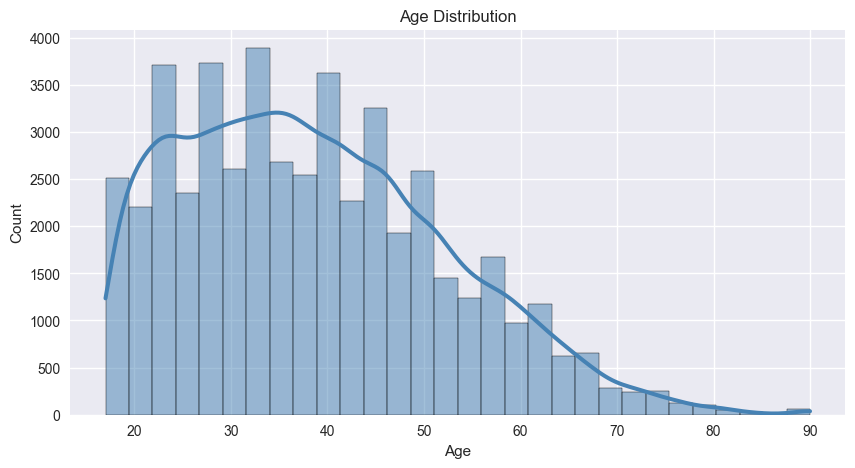

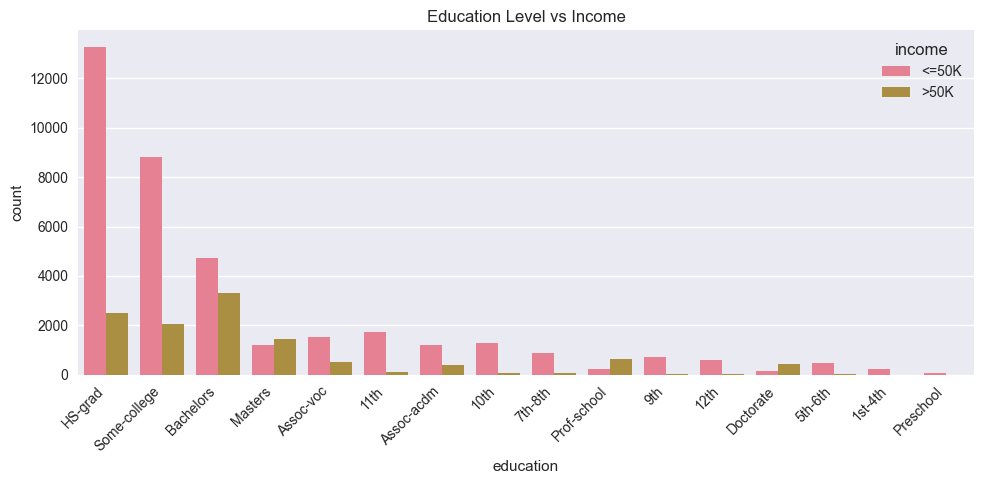

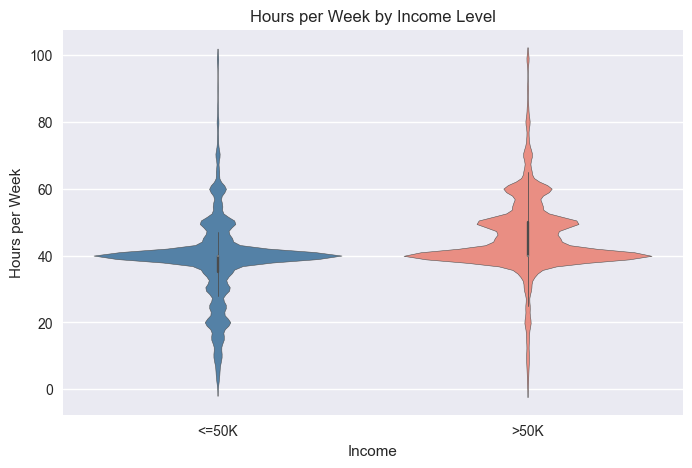

In [162]:
# visualize the distribution of the target variable

# Figure1: incom distribution  
plt.figure(figsize=(10, 5))
sns.countplot(x='income', data=df,
              hue='income',
              palette={'<=50K': 'steelblue', '>50K': 'salmon'},
              legend=False)
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()

print(df['income'].value_counts(normalize=True).round(4))

# Figure2: age distribution 
plt.figure(figsize=(10,5))
sns.histplot(df['age'], bins=30, kde=True,
             color='steelblue',
             line_kws={'color': 'darkblue', 
                       'linewidth': 2.9})
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


# Figure3: education
plt.figure(figsize=(10,5))
sns.countplot(x='education', hue='income', data=df, 
              order=df['education'].value_counts().index)
plt.title('Education Level vs Income')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Figure4: hours-per-week by income 
plt.figure(figsize=(8,5))
sns.violinplot(x='income', y='hours-per-week', data=df,
               hue='income',              # ← add this
               palette=['steelblue', 'salmon'],
               legend=False,              # ← add this
               inner='box')
plt.title('Hours per Week by Income Level')
plt.xlabel('Income')
plt.ylabel('Hours per Week')
plt.show()

###  Learnings from Numerical Visualization


### Figure 1: Incom distribution (bar chart)
**How balanced is our target variable 
between the two income classes?**

The chart shows that:
<=50k bar: 37000 people (about 76% of the dataset have less then or equal 50k a year )
(>50k bar: 12000 people (about 24% of the dataset have greater then 50k a year))

### Figure 2: Age distribution (histogram)
**What is the age profile of people 
in this dataset?**

 Distribution peaks around **mid-to-late 30s** 
  (mean: 38.6, median: 37) **Slightly right-skewed** — small number of older 
  people pull the mean above the median
- Middle 50% falls between **28 and 48 years old**

### Figure 3: Education vs Income (grouped bar chart)
**Does education level affect the 
likelihood of earning more than $50K?**

The proportion of olive (>50K) vs pink (<=50K) bars within each education category. 
as education level increases (HS-grad → Some-college → Bachelors → Masters → Doctorate and Prof-school), the share of >50K grows noticeably.This is the chart that visually proves education is a meaningful predictor of income(correlation: **0.333**).

### Figure 4: Hours-per-week by Income (Violin Plot)
**Do high earners work more hours 
than low earners?**

Yes — the violin plot confirms this:

- **`<=50K`** — median at **40 hours**, wide flat shape 
  showing most people work exactly the standard work week
- **`>50K`** — median noticeably **above 40 hours**, 
  wider spread between 40–60hrs, with a visible 
  bulge at **~50 hours/week**

**Key insight:** both groups peak at 40 hours, but 
`>50K` earners work longer and more varied hours — 
The violin reveals that many high earners specifically cluster at **50 hours/week**, not just "above 40" in general,
meaning people earning more tend to work more hours per week. 

### 1.5.2 Visualization of Categorical Features

In [163]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [164]:
# get the unique values of the occupation column
print(repr(df['occupation'].unique()))

array(['Adm-clerical', 'Exec-managerial', 'Handlers-cleaners',
       'Prof-specialty', 'Other-service', 'Sales', 'Craft-repair',
       'Transport-moving', 'Farming-fishing', 'Machine-op-inspct',
       'Tech-support', 'Unknown', 'Protective-serv', 'Armed-Forces',
       'Priv-house-serv'], dtype=object)


In [165]:
# get the name of the columns in the dataset
print(df.columns.tolist())
print()

# get the shape of the dataset
print(df.shape)
print()

# get the first 10 rows of selected columns
print(df[['occupation','relationship','race','sex','native-country','income']].head(10))
print()
print(df['occupation'].value_counts())
print()
print(df['native-country'].value_counts())

['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

(48842, 15)

          occupation   relationship   race     sex native-country income
0       Adm-clerical  Not-in-family  White    Male  United-States  <=50K
1    Exec-managerial        Husband  White    Male  United-States  <=50K
2  Handlers-cleaners  Not-in-family  White    Male  United-States  <=50K
3  Handlers-cleaners        Husband  Black    Male  United-States  <=50K
4     Prof-specialty           Wife  Black  Female           Cuba  <=50K
5    Exec-managerial           Wife  White  Female  United-States  <=50K
6      Other-service  Not-in-family  Black  Female        Jamaica  <=50K
7    Exec-managerial        Husband  White    Male  United-States   >50K
8     Prof-specialty  Not-in-family  White  Female  United-States   >50K
9    Exec-managerial        Husband  White    Male  Un

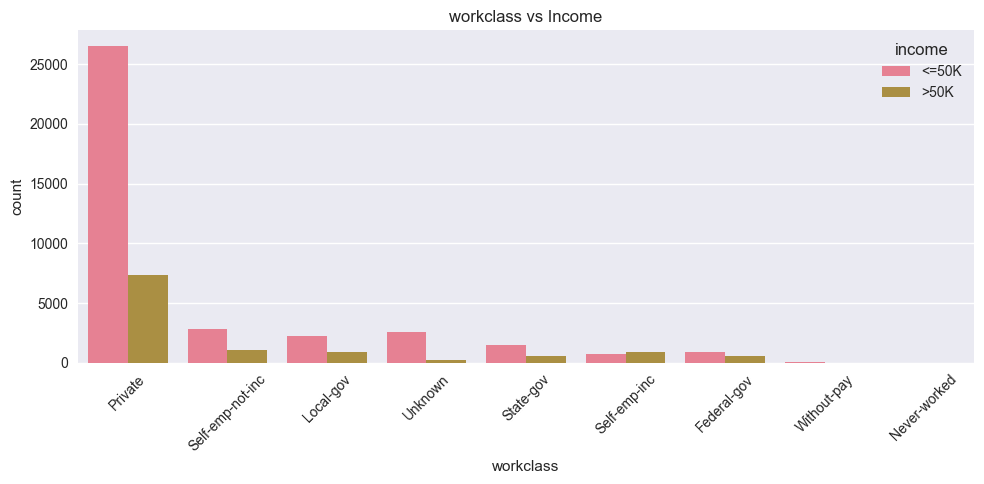

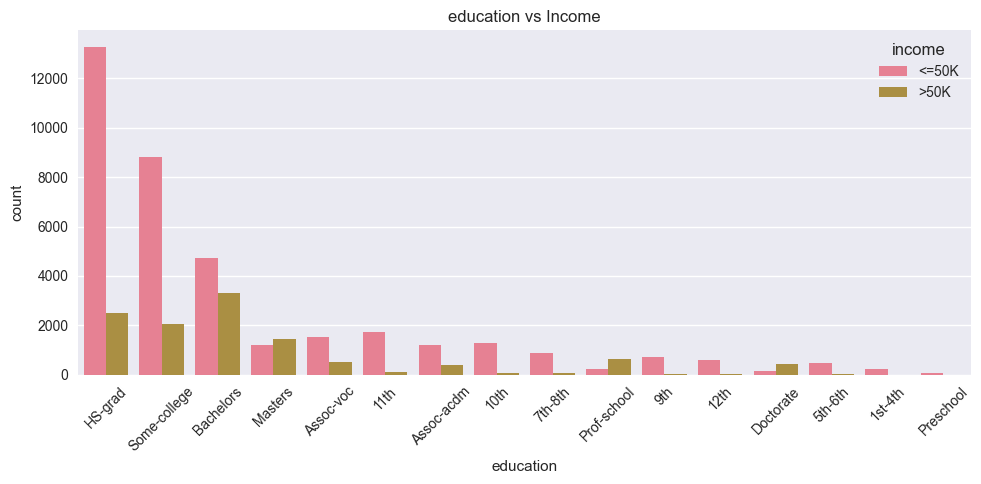

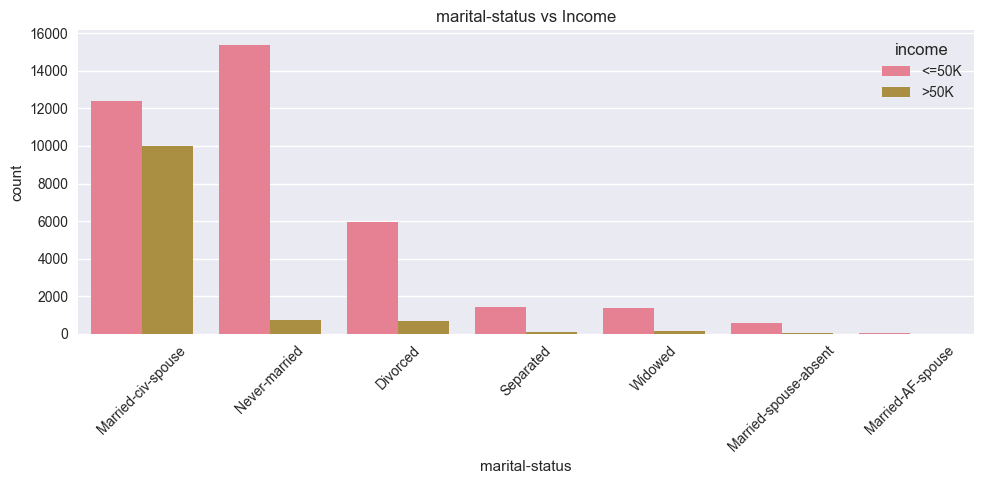

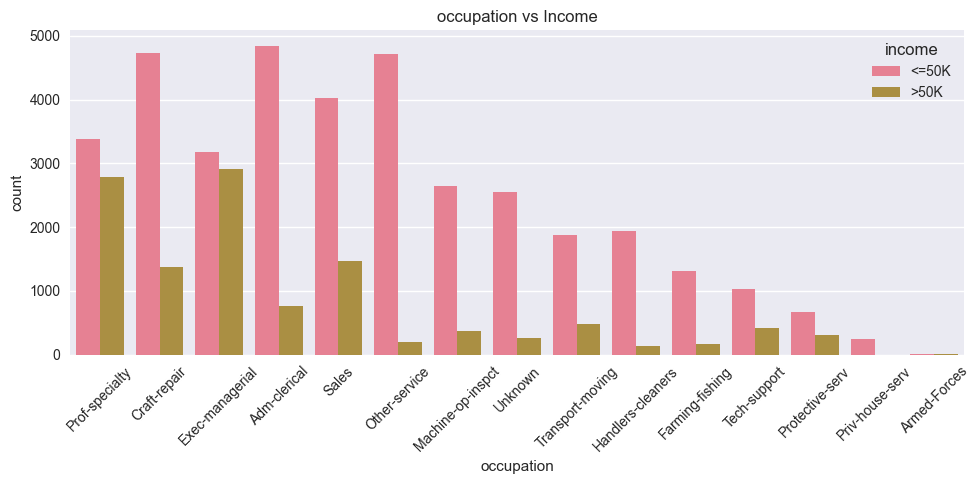

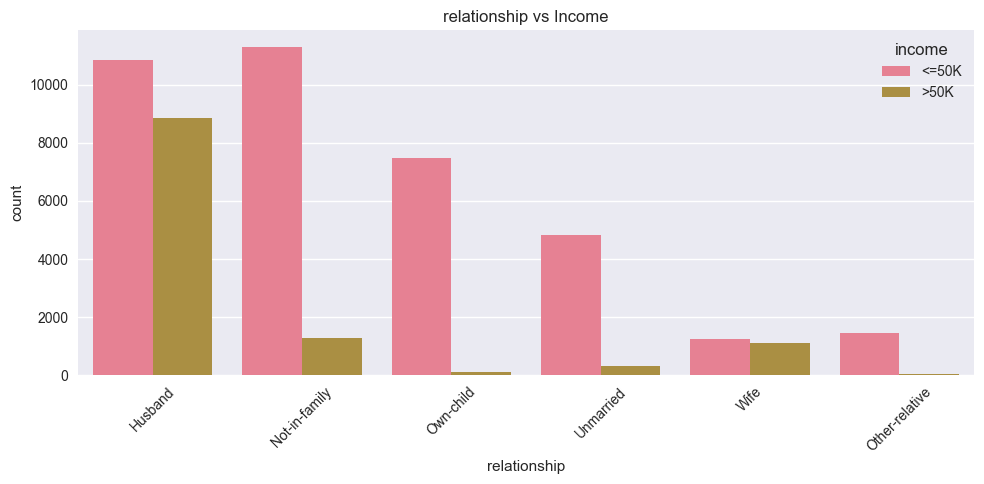

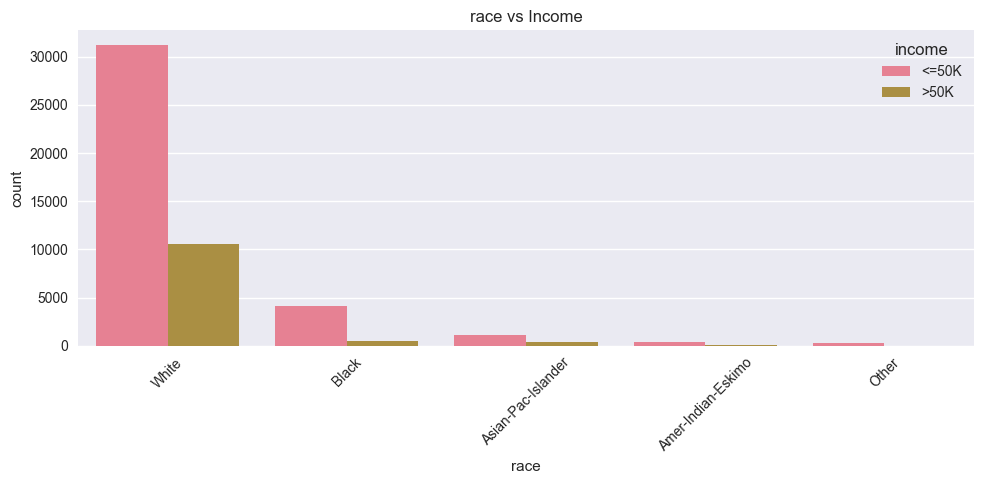

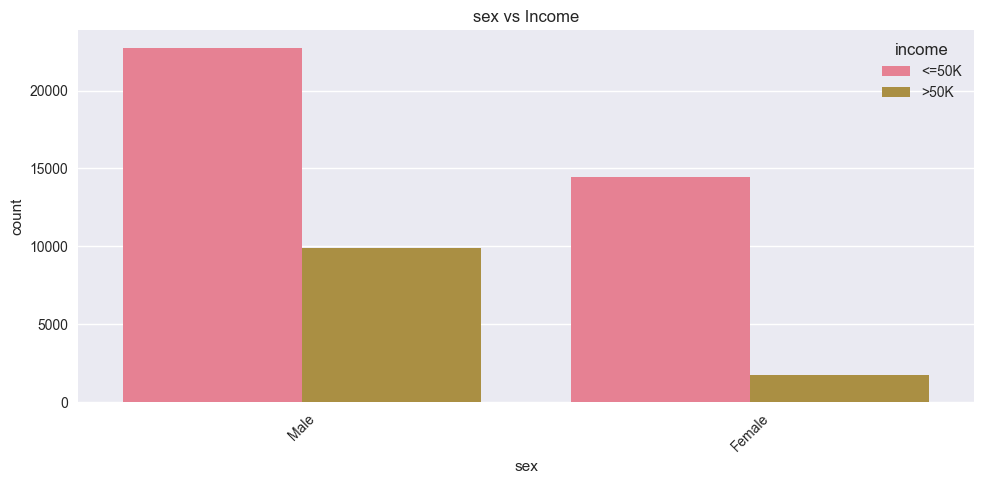

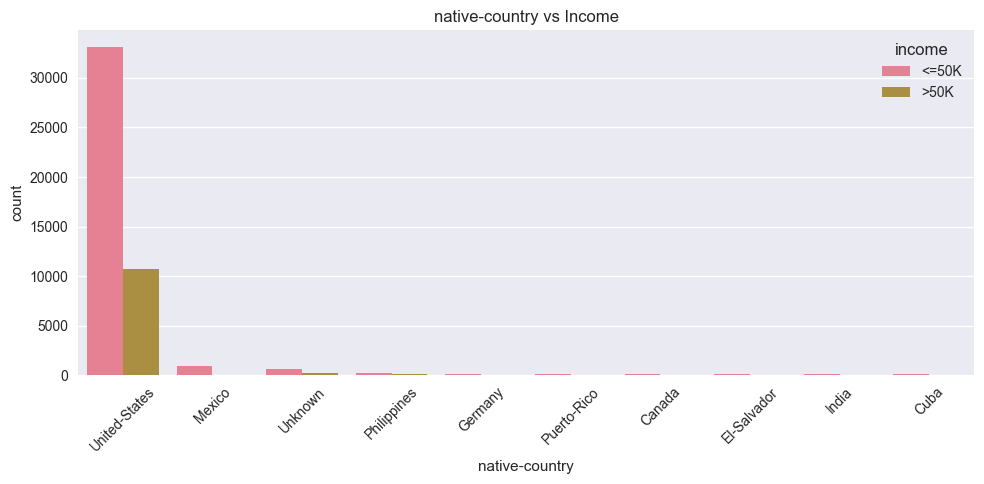

In [166]:
# Visualization of Categorical Features 
categorical_features = ['workclass', 'education', 'marital-status', 'occupation',
                         'relationship', 'race', 'sex', 'native-country']

for feature in categorical_features:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    if feature == 'native-country':
        top = df[feature].value_counts().head(10).index
        data = df[df[feature].isin(top)]
        order = top
    else:
        data = df
        order = df[feature].value_counts().index
    
    sns.countplot(x=feature, hue='income', data=data, order=order, ax=ax)
    ax.set_title(f'{feature} vs Income')
    ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

###  Learnings from Categorical Visualization
  (Final insights — categorical features vs income)

1- **Workclass** — Self-emp-inc stands out sharply at 55.3% >50K, more than double Private (21.8%), the most common category. Self-employment with incorporation is a strong positive signal.

2- **Education** — Higher education levels (Bachelors, Masters,Prof-school,andDoctorate) show a clearly growing share of >50K, while HS-grad and below stay low. One of the cleanest, most intuitive predictors in the dataset.

3- **Marital-status** — The single biggest split we found: Married-civ-spouse at 44.6% vs Never-married at just 4.5% — nearly a 10x gap. Very strong predictor, though likely entangled with age (married people tend to be older/established).

4- **Occupation** — Exec-managerial (47.8%) and Prof-specialty (45.1%) sit far above Priv-house-serv (1.2%) and Other-service (4.1%). Likely one of your strongest individual predictors.

5- **Relationship** — Wife (46.9%) and Husband (44.9%) dominate over Own-child (1.5%). Strongly overlaps with marital-status — flagged earlier as a potential redundancy/multicollinearity concern to check in the correlation matrix.

6- **Race** — Asian-Pac-Islander (26.9%) and White (25.4%) sit roughly 2x above Black (12.1%) and Amer-Indian-Eskimo (11.7%). A real but moderate signal, also worth noting as a fairness consideration if this model were ever used in a real-world decision context.

7- **Sex** — Male (30.4%) vs Female (10.9%) — about a 3x gap. Reflects real, documented patterns in this 1990s census data (occupational segregation, historical wage gap); also worth noting as a fairness consideration if this model were ever used in a real-world decision context.

8- **Native-country** — Mostly dominated by United-States (~90% of rows). Among the top 10 countries, India (41.1%) and Canada (34.6%) actually exceed the U.S. rate (24.4%), while Mexico sits low (4.9%). Real variation exists, but weaker overall predictive power given the heavy U.S. skew in volume.

## Phase 2: Encoding, Modeling & Evaluation

### 2.1 Feature Engineering and Encoding

In [167]:
# we will drowp the most unwanted fearturs 
df_model = df.drop(['fnlwgt','education'], axis=1) # axis 1 to drowwp the colunm
print(df_model.columns.tolist())
print(df_model.shape)


['age', 'workclass', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
(48842, 13)


**2.1.1 Dropping Redundant & Irrelevant Features**

Two columns dropped before modeling:

- **`fnlwgt`** — census sampling weight, not a personal 
  characteristic, adds noise not signal
- **`education`** — text version of `education-num`, 
  keeping both would be redundant since they contain 
  identical information

Remaining features: **13 columns** (down from 15)

In [168]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_model['income']= le.fit_transform(df['income'])
print(le.classes_)# meaning <=50K → 0, >50K → 1
print(df_model['income'].value_counts())

['<=50K' '>50K']
income
0    37155
1    11687
Name: count, dtype: int64


**2.1.2 Encoding the Target Variable**

`LabelEncoder` converts the text `income` column into binary numbers:
- `<=50K` → **0** (majority class, 37,155 rows, ~76%)
- `>50K`  → **1** (minority class, 11,687 rows, ~24%)


In [169]:
# show the first 5 rows of the dataset after encoding the target variable
df_model.head()
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
print('Columns to encode:', categorical_cols)

df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

print(df_encoded.shape)
df_encoded.head()

Columns to encode: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
(48842, 85)


,age,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Unknown,native-country_Vietnam,native-country_Yugoslavia
0,39,13,2174,0,40,0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,50,13,0,0,13,0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,38,9,0,0,40,0,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
3,53,7,0,0,40,0,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
4,28,13,0,0,40,0,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


### 2.2 Correlation Analysis

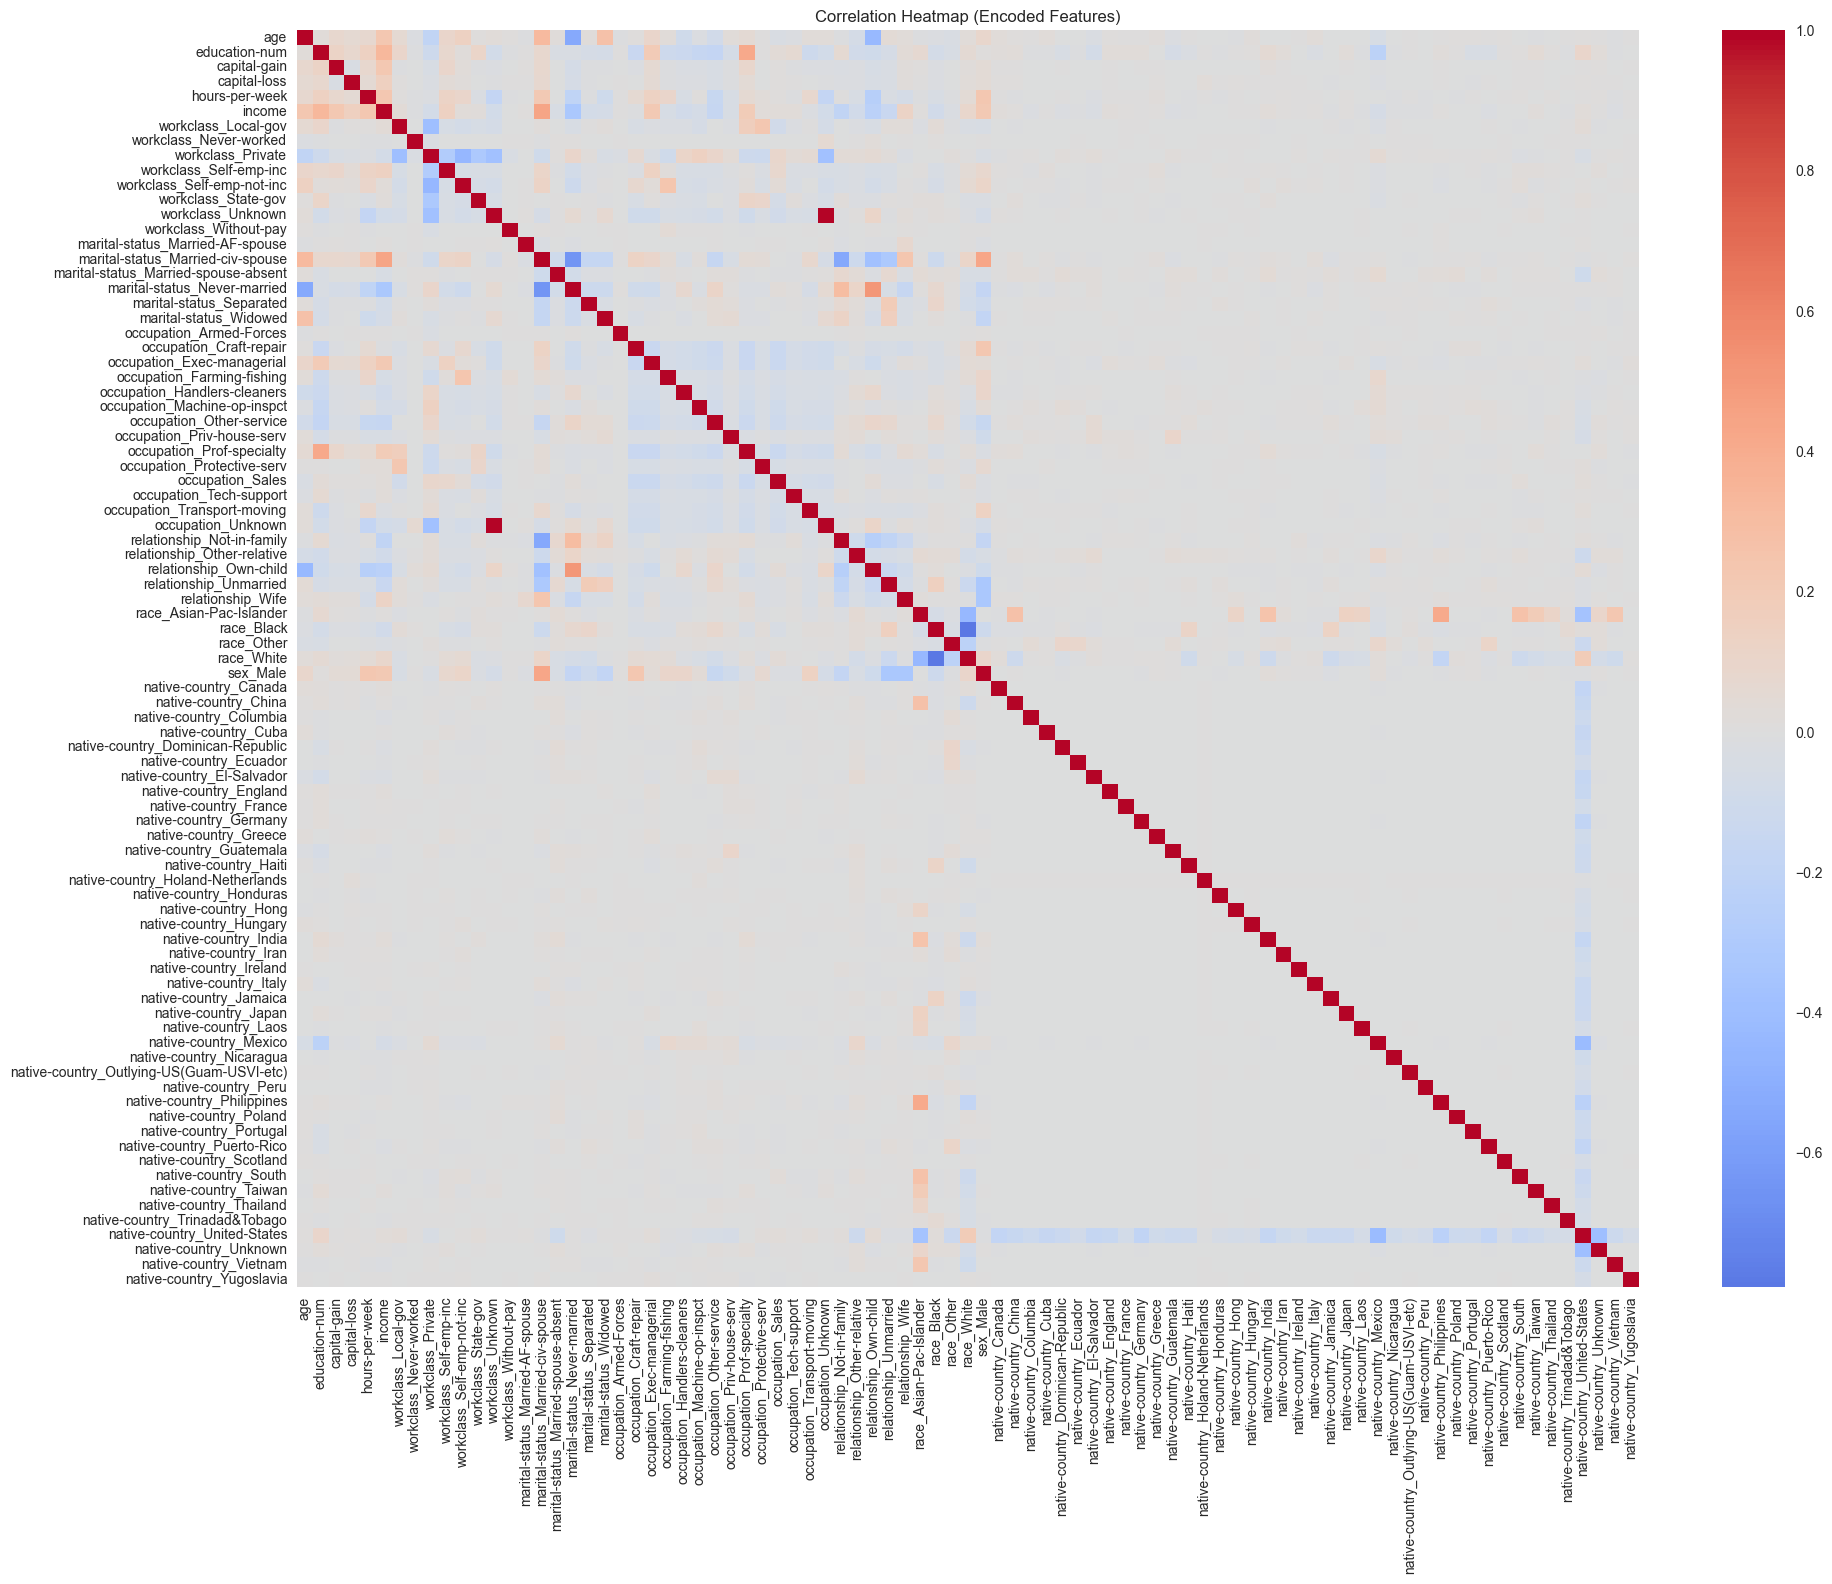

In [170]:
# the correlation heatmap of the encoded features (messy matrix)
plt.figure(figsize=(20, 16))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Encoded Features)')
plt.tight_layout()
plt.show()

In [171]:
# clear way to see the correlation of each feature with the target variable (income)

corr_with_income = df_encoded.corr()['income'].sort_values(ascending=False)

print("TOP 15 POSITIVE correlations with income:")
print(corr_with_income.head(15).round(3))
print()
print("TOP 15 NEGATIVE correlations with income:")
print(corr_with_income.tail(15).round(3))

TOP 15 POSITIVE correlations with income:
income                               1.000
marital-status_Married-civ-spouse    0.446
education-num                        0.333
age                                  0.230
hours-per-week                       0.228
capital-gain                         0.223
sex_Male                             0.215
occupation_Exec-managerial           0.211
occupation_Prof-specialty            0.189
capital-loss                         0.148
workclass_Self-emp-inc               0.140
relationship_Wife                    0.120
race_White                           0.084
workclass_Local-gov                  0.035
native-country_United-States         0.033
Name: income, dtype: float64

TOP 15 NEGATIVE correlations with income:
native-country_Mexico          -0.063
marital-status_Widowed         -0.065
occupation_Machine-op-inspct   -0.070
marital-status_Separated       -0.074
workclass_Private              -0.076
workclass_Unknown              -0.084
occupation_Un

**Top positive signals**:
`marital-status_Married-civ-spouse` (0.446) and 
`education-num` (0.333) are the strongest predictors 
of high income — confirming our Phase 1 findings.

**Top negative signals:**
`marital-status_Never-married` (-0.319) and 
`relationship_Own-child` (-0.226) are the strongest 
predictors of low income.

> **Key Takeaway:** the correlation analysis confirms 
> what Phase 1 visualizations already suggested — 
> marital status, education, occupation, and age 
> are the most influential features in predicting 
> whether someone earns `>50K`.

### 2.3 Model Training & Evaluation

#### 2.3.1 Train/Test Split

In [172]:
# information about the features and target variable
X = df_encoded.drop('income', axis=1)
y = df_encoded['income']

print('X shape:', X.shape)
print('y shape:', y.shape)
print('y value counts:')
print(y.value_counts())

X shape: (48842, 84)
y shape: (48842,)
y value counts:
income
0    37155
1    11687
Name: count, dtype: int64


In [173]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # reproducible split every time
    stratify=y            # keeps the 76/24 ratio in both train and test
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print()
print('Train class balance:')
print(y_train.value_counts(normalize=True).round(3))
print()
print('Test class balance:')
print(y_test.value_counts(normalize=True).round(3))

X_train shape: (39073, 84)
X_test shape: (9769, 84)

Train class balance:
income
0    0.761
1    0.239
Name: proportion, dtype: float64

Test class balance:
income
0    0.761
1    0.239
Name: proportion, dtype: float64


 ###  Train/Test Split insights 

The full dataset (48,842 rows) is split into:
- **Training set (80%):** 39,073 rows — model learns from here
- **Test set (20%):** 9,769 rows — model gets evaluated here

> The model never sees test data during training — 
> this guarantees an honest, unbiased evaluation.

### 2.3.2 Scaling for Logistic Regression

In [174]:
# Since we are using logistic regration we need to do scaling before training 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# X_train_scaled AND X_test_scaled are for logistic regression 
# X_train/X_test for Decision Tree and Random Forest

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('X_train_scaled shape:', X_train_scaled.shape)
print('X_test_scaled shape:', X_test_scaled.shape)
print()
print('First row of X_train_scaled (sample of scaled values):')
print(X_train_scaled[0].round(3))



X_train_scaled shape: (39073, 84)
X_test_scaled shape: (9769, 84)

First row of X_train_scaled (sample of scaled values):
[-0.12   1.138 -0.144 -0.216 -0.845 -0.263 -0.014  0.663 -0.19  -0.292
 -0.204 -0.246 -0.022 -0.027 -0.922 -0.114  1.43  -0.181 -0.18  -0.019
 -0.377 -0.378 -0.177 -0.212 -0.259 -0.333 -0.072 -0.379 -0.145  2.803
 -0.172 -0.227 -0.247  1.698 -0.179 -0.427 -0.342 -0.223 -0.179 -0.325
 -0.093  0.412 -1.424 -0.06  -0.05  -0.042 -0.054 -0.047 -0.032 -0.056
 -0.05  -0.028 -0.064 -0.031 -0.042 -0.039 -0.005 -0.019 -0.025 -0.02
 -0.056 -0.035 -0.025 -0.046 -0.046 -0.042 -0.022 -0.144 -0.03  -0.019
 -0.031 -0.077 -0.044 -0.04  -0.061 -0.021 -0.05  -0.037 -0.024 -0.021
  0.338 -0.134 -0.041 -0.021]


#### 2.3.3 Training Original Models

In [175]:
# Train the 3 models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Model 1: Logistic Regression (uses scaled data)
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

# Model 2: Decision Tree (uses unscaled data)
print("Training Decision Tree...")
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Model 3: Random Forest (uses unscaled data)
print("Training Random Forest...")
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print()
print("All three models trained successfully")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...

All three models trained successfully


#### 2.3.4 Evaluating Original Models

In [176]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
    'Logistic Regression': lr_pred,
    'Decision Tree': dt_pred,
    'Random Forest': rf_pred
}

for name, pred in models.items():
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"Accuracy: {accuracy_score(y_test, pred):.4f}")
    print()
    print("Classification Report:")
    print(classification_report(y_test, pred, target_names=['<=50K', '>50K']))
    print()

  Logistic Regression
Accuracy: 0.8513

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      7431
        >50K       0.73      0.60      0.66      2338

    accuracy                           0.85      9769
   macro avg       0.81      0.77      0.78      9769
weighted avg       0.84      0.85      0.85      9769


  Decision Tree
Accuracy: 0.8276

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.89      0.89      7431
        >50K       0.64      0.63      0.64      2338

    accuracy                           0.83      9769
   macro avg       0.76      0.76      0.76      9769
weighted avg       0.83      0.83      0.83      9769


  Random Forest
Accuracy: 0.8512

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.90      7431
        >50K       0.71      0.63      0.67      2338

   

#### 2.3.5 Training Balanced Models

If F1 for class 1 (>50K) is very low (below 0.60)
       → then apply class_weight='balanced' and retrain is needed
If F1 for class 1 (>50K) is reasonable (above 0.65)
        → no handling needed

After evaluating the original 3 models, we observed 
that all three showed **low recall on `>50K`** (0.60–0.63)
— meaning they were missing 37–40% of actual high earners,
defaulting toward the majority class (`<=50K`) due to 
the 76/24 class imbalance.        

In [177]:
# Retrain with class_weight='balanced'
lr_bal = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_bal.fit(X_train_scaled, y_train)
lr_bal_pred = lr_bal.predict(X_test_scaled)

dt_bal = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_bal.fit(X_train, y_train)
dt_bal_pred = dt_bal.predict(X_test)

rf_bal = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
rf_bal.fit(X_train, y_train)
rf_bal_pred = rf_bal.predict(X_test)

print("All balanced models trained successfully")


All balanced models trained successfully


#### 2.3.6 Evaluating Balanced Models

In [178]:
for name, pred in [('Logistic Regression balanced', lr_bal_pred),
                    ('Decision Tree balanced', dt_bal_pred),
                    ('Random Forest balanced', rf_bal_pred)]:
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, pred, target_names=['<=50K', '>50K']))

  Logistic Regression balanced
              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.86      7431
        >50K       0.57      0.83      0.67      2338

    accuracy                           0.81      9769
   macro avg       0.75      0.82      0.77      9769
weighted avg       0.85      0.81      0.82      9769

  Decision Tree balanced
              precision    recall  f1-score   support

       <=50K       0.89      0.86      0.88      7431
        >50K       0.60      0.67      0.63      2338

    accuracy                           0.82      9769
   macro avg       0.75      0.77      0.76      9769
weighted avg       0.82      0.82      0.82      9769

  Random Forest balanced
              precision    recall  f1-score   support

       <=50K       0.91      0.87      0.89      7431
        >50K       0.63      0.74      0.68      2338

    accuracy                           0.83      9769
   macro avg       0.77      0.80      0.78    

### 2.4 Model Selection — Final Recommendation

#### Complete Model Comparison — Original vs Balanced

After retraining with `class_weight='balanced'`, we 
compare all 6 models side by side to identify which 
performs best for our specific purpose.

| Model | Accuracy | Precision `>50K` | Recall `>50K` | F1 `>50K` |
|---|---|---|---|---|
| Logistic Regression | 85.13% | 0.73 | 0.60 | 0.66 |
| **LR Balanced**| **81.00%** | **0.57** | **0.83** | **0.67** |
| Decision Tree | 82.76% | 0.64 | 0.63 | 0.64 |
| DT Balanced | 82.00% | 0.60 | 0.67 | 0.63 |
| Random Forest | 85.12% | 0.71 | 0.63 | 0.67 |
|**RF Balanced ✅** | **83.00%** | **0.63** | **0.74** | **0.68** |

---

#### Why F1-score Is Our Primary Metric

The 76/24 class imbalance means accuracy alone is 
misleading — a model predicting `<=50K` for everyone 
would score 76% accuracy without learning anything useful.
F1-score balances precision and recall, giving a more 
honest measure of real performance on both classes.

---

#### No Single "Best" Model — Context Decides

| Metric | Priority | Best Model |
|---|---|---|
| **Recall** | Catching every high earner | **LR Balanced** (0.83) |
| **F1-score** | Overall balanced performance | **RF Balanced** (0.68) |



---




#### The goal of this evaluation is not to find one universal winner — but to identify which model best fits each specific application context like:
> - **In LR Balanced Model recall matters more than precision**, LR Balanced's high recall (0.83) — even at the cost of lower precision (0.57) → best when missing a high earner is costly matters more in (financial/business applications).
>
> - **In RF Balanced Model F1-score matters more than recall alone** Not too many missed high earners (recall: 0.74) or false alarms (precision: 0.63) and overall correctness (accuracy: 83% ) → best when overall balance matters more (academic/research applications).
>



> **The right model depends entirely on what type of mistake your use case can tolerate.**

### 2.5 Feature Importance & AUC Analysis

In [179]:
from sklearn.metrics import roc_auc_score

print('=== AUC Scores (higher = better) ===')
print()
print('Original models:')
print('LR AUC:          ', round(roc_auc_score(y_test, lr_pred), 3))
print('DT AUC:          ', round(roc_auc_score(y_test, dt_pred), 3))
print('RF AUC:          ', round(roc_auc_score(y_test, rf_pred), 3))
print()
print('Balanced models:')
print('LR Balanced AUC: ', round(roc_auc_score(y_test, lr_bal_pred), 3))
print('DT Balanced AUC: ', round(roc_auc_score(y_test, dt_bal_pred), 3))
print('RF Balanced AUC: ', round(roc_auc_score(y_test, rf_bal_pred), 3))

=== AUC Scores (higher = better) ===

Original models:
LR AUC:           0.766
DT AUC:           0.76
RF AUC:           0.775

Balanced models:
LR Balanced AUC:  0.816
DT Balanced AUC:  0.765
RF Balanced AUC:  0.801


=== Top 15 Most Important Features (RF Balanced) ===
                          feature  importance
                              age    0.228665
                    education-num    0.122036
                   hours-per-week    0.108413
marital-status_Married-civ-spouse    0.098022
                     capital-gain    0.081402
     marital-status_Never-married    0.056889
                     capital-loss    0.027569
       relationship_Not-in-family    0.024890
                         sex_Male    0.024330
           relationship_Own-child    0.022615
       occupation_Exec-managerial    0.016766
        occupation_Prof-specialty    0.016369
         occupation_Other-service    0.015084
           relationship_Unmarried    0.014540
                relationship_Wife    0.010188


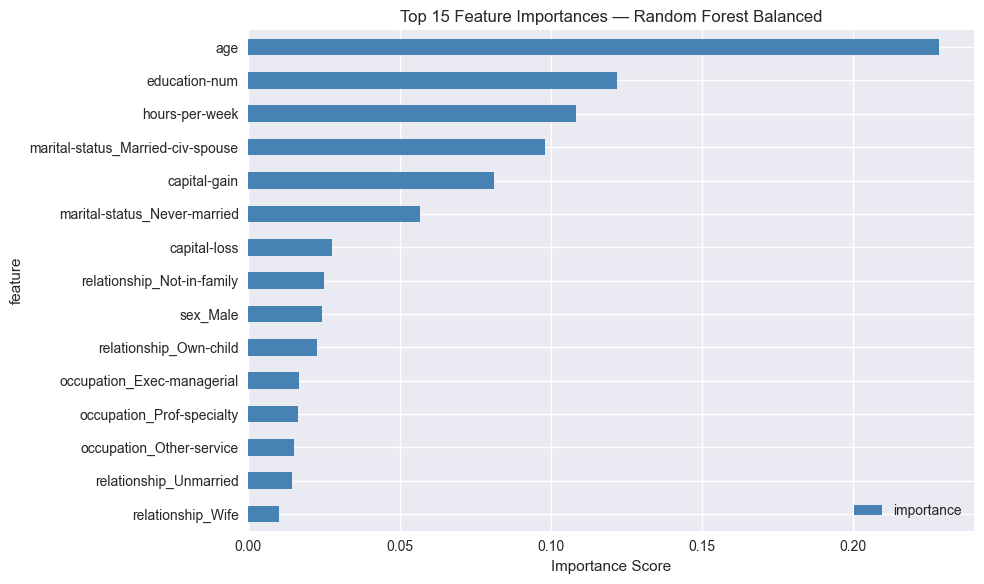

In [180]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from Random Forest Balanced
feature_names = X.columns.tolist()
importances = rf_bal.feature_importances_

# Put into a dataframe and sort
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Show top 15
print('=== Top 15 Most Important Features (RF Balanced) ===')
print(importance_df.head(15).to_string(index=False))

# Plot top 15
plt.figure(figsize=(10, 6))
importance_df.head(15).plot(
    kind='barh',
    x='feature',
    y='importance',
    ax=plt.gca(),
    color='steelblue'
)
plt.title('Top 15 Feature Importances — Random Forest Balanced')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

=== Top 15 Most Important Features (LR Balanced) ===
                          feature  coefficient
                     capital-gain     2.278243
marital-status_Married-civ-spouse     1.157064
                    education-num     0.733787
       occupation_Priv-house-serv    -0.441309
                   hours-per-week     0.424911
                              age     0.420606
                         sex_Male     0.370954
                relationship_Wife     0.279315
       workclass_Self-emp-not-inc    -0.274649
       occupation_Exec-managerial     0.265879
       relationship_Not-in-family     0.260993
                     capital-loss     0.258457
                workclass_Private    -0.256766
         occupation_Other-service    -0.241151
        occupation_Prof-specialty     0.221295


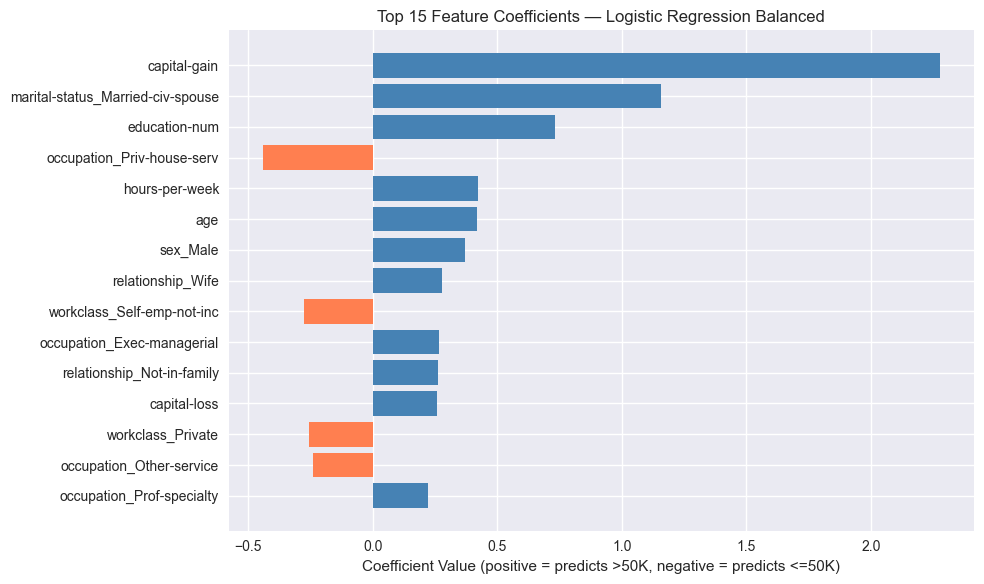

In [181]:
import numpy as np

# Get coefficients from Logistic Regression Balanced
lr_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': lr_bal.coef_[0]
})

# Sort by absolute value (strength of effect regardless of direction)
lr_importance['abs_coefficient'] = lr_importance['coefficient'].abs()
lr_importance = lr_importance.sort_values('abs_coefficient', ascending=False)

# Show top 15
print('=== Top 15 Most Important Features (LR Balanced) ===')
print(lr_importance.head(15)[['feature', 'coefficient']].to_string(index=False))

# Plot top 15
plt.figure(figsize=(10, 6))
colors = ['steelblue' if c > 0 else 'coral' 
          for c in lr_importance.head(15)['coefficient']]
plt.barh(lr_importance.head(15)['feature'], 
         lr_importance.head(15)['coefficient'],
         color=colors)
plt.title('Top 15 Feature Coefficients — Logistic Regression Balanced')
plt.xlabel('Coefficient Value (positive = predicts >50K, negative = predicts <=50K)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

###  Feature Importance & AUC Analysis Insights

#### Random Forest Balanced — Top Features
| Feature | Importance |
|---|---|
| `age` | 0.229 |
| `education-num` | 0.122 |
| `hours-per-week` | 0.108 |
| `marital-status_Married-civ-spouse` | 0.098 |
| `capital-gain` | 0.081 |

>
> RF spreads importance across many features — no single 
> variable dominates, reflecting real-world complexity.

#### Logistic Regression Balanced — Top Coefficients
| Feature | Coefficient | Effect |
|---|---|---|
| `capital-gain` | +2.278 | Strongest push toward `>50K` |
| `marital-status_Married-civ-spouse` | +1.157 | Strong positive signal |
| `education-num` | +0.734 | Positive signal |
| `occupation_Priv-house-serv` | -0.441 | Strong push toward `<=50K` |
| `sex_Male` | +0.371 | Directly encodes sex as predictor |

> LR relies heavily on `capital-gain` (coefficient 2.278) 
> and directly encodes `sex_Male` as a positive predictor — 
> making it more sensitive to demographic characteristics 
> than Random Forest.

#### Key Differences Between Models
- **RF** learns income as a combination of many features together
- **LR** relies heavily on `capital-gain` as a dominant single signal
- **LR** more directly encodes `sex_Male` as a predictor (coefficient: +0.371)
  vs RF where sex has much lower relative importance (0.024)

#### Fairness Note
Both models reflect real patterns in **1994 Census data** — 
the sex and race disparities are genuine historical inequalities, 
not modeling errors. However, any real-world application of 
these models should include a proper **fairness audit** before 
deployment to avoid perpetuating historical biases.

### 2.6 Confusion Matrix

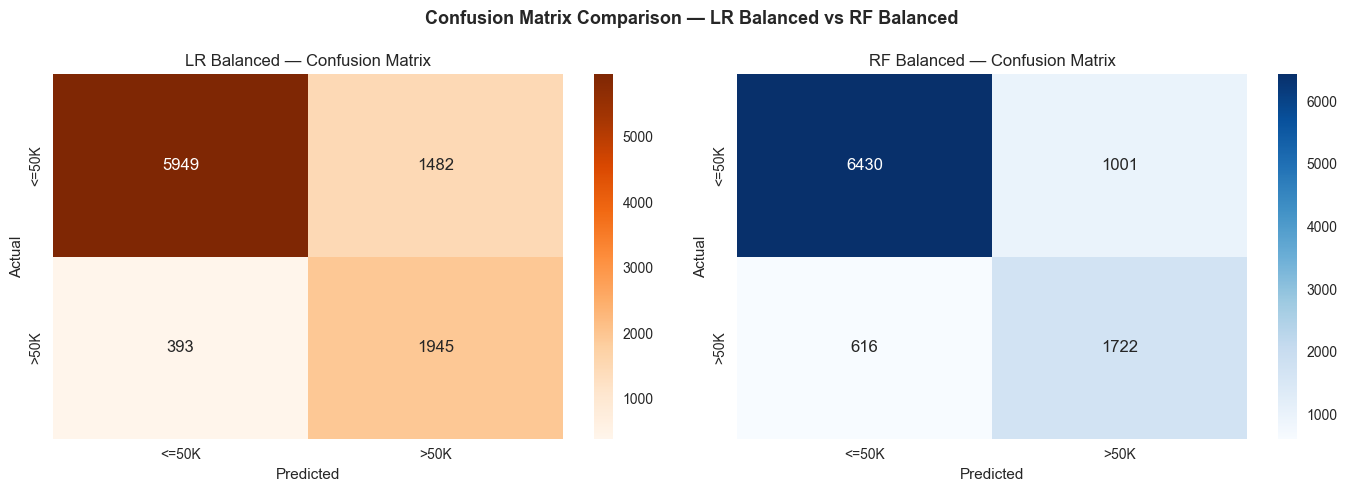

In [182]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix 1 — LR Balanced
cm_lr = confusion_matrix(y_test, lr_bal_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'],
            ax=axes[0])
axes[0].set_title('LR Balanced — Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Confusion Matrix 2 — RF Balanced
cm_rf = confusion_matrix(y_test, rf_bal_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'],
            ax=axes[1])
axes[1].set_title('RF Balanced — Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle('Confusion Matrix Comparison — LR Balanced vs RF Balanced',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Confusion Matrix — LR Balanced vs RF Balanced Insights

A confusion matrix shows exactly where each model 
makes correct and incorrect predictions, broken into 4 cells:

| Cell | Meaning |
|---|---|
| **Top-left** | Correctly predicted `<=50K` (True Negatives) |
| **Top-right** | Predicted `>50K` but actually `<=50K` (False Positives) |
| **Bottom-left** | Predicted `<=50K` but actually `>50K` (False Negatives) |
| **Bottom-right** | Correctly predicted `>50K` (True Positives) |

#### LR Balanced Results
- ✅ Correctly identified the most `>50K` earners (high True Positives)
- ⚠️ Most False Positives — flags more `<=50K` people as high earners
- **Best for:** use cases where missing a high earner is costly

#### RF Balanced Results
- ✅ Fewer False Positives — more conservative, fewer false alarms
- ⚠️ More False Negatives — misses more actual high earners than LR
- **Best for:** use cases where overall balance matters more

#### Key Takeaway
> **LR Balanced** misses fewer high earners (low False Negatives)
> but raises more false alarms (high False Positives).
> **RF Balanced** raises fewer false alarms but misses 
> more high earners — a classic **precision vs recall trade-off.**
>


### 2.7 Model Performance Summary

### 2.7.1 When to Use Each Model

#### LR Balanced
> *"I must catch as many `>50K` people as possible, 
> even if I flag some `<=50K` people incorrectly"*

**Best for:**
- Targeting financial products at high earners
- Any use case where **missing a high earner is costly**
- When **recall matters more than precision**

---

#### RF Balanced
> *"I want the best overall balance — not too many 
> false alarms, not too many missed high earners"*

**Best for:**
- Academic research and general income analysis
- Any use case where **overall balance matters more**
- When **F1-score matters more than recall alone**

---

| | LR Balanced | RF Balanced |
|---|---|---|
| **Priority** | Catch most high earners | Overall balance |
| **Recall** | 0.83 ✅ | 0.74 |
| **Precision** | 0.57 | 0.63 ✅ |
| **F1** | 0.67 | 0.68 ✅ |
| **AUC** | 0.816 ✅ | 0.801 |
| **Best when** | Missing `>50K` is costly | False alarms are costly |



### 2.7.2 Who Earns More Than $50K Summary?
Based on our analysis and modeling results, 
a high earner in this 1994 U.S. Census data typically is:

| Feature | High Earner Signal |
|---|---|
| **Marital Status** | Married-civ-spouse (44.6% earn >50K vs 4.5% Never-married) |
| **Education** | Bachelors, Masters, Doctorate — correlation: **0.333** |
| **Occupation** | Exec-managerial (47.8%) or Prof-specialty (45.1%) |
| **Workclass** | Self-emp-inc (55.3%) vs Private (21.8%) |
| **Age** | Older — correlation: **0.230** |
| **Hours/week** | Works more than standard 40hrs — correlation: **0.228** |
| **Capital gain** | ANY gain → 61.7% chance of >50K vs 20.5% with none |
| **Sex** | Male (30.4%) vs Female (10.9%) — reflects 1990s wage gap |

### The Big Picture

> Both recommended models correctly classify income 
> **83% of the time (RF Balanced)** and **81% (LR Balanced)**,
> identifying **3 out of every 4 actual high earners.**

Most confident predicting `>50K` for someone who is:
**married, college-educated, in management or a professional 
role, self-employed or in government, older, working long 
hours, and reporting capital gains.**

## 3. Conclusion

### Project Summary
This project built and evaluated a binary classification pipeline
to predict whether a person earns more than $50,000 annually,
using 1994 U.S. Census data (48,842 records, 15 features).

### Key Findings

**Data insights:**
- `marital-status`, `occupation`, and `education` are the 
  strongest predictors of income
- `capital-gain`, despite 75% of values being zero, is the 
  **single most powerful signal** in Logistic Regression (coefficient: 2.278)
- Random Forest spreads importance across many features — 
  `age` (0.229), `education-num` (0.122), `hours-per-week` (0.108)

**Modeling insights:**
- `class_weight='balanced'` significantly improved minority 
  class performance across all three models
- Decision Tree was weakest overall — prone to overfitting
- Both LR Balanced and RF Balanced are strong candidates 
  depending on the use case

### Final Model Recommendation

| Priority | Best Model | Key Metric |
|---|---|---|
| Catch most high earners | **LR Balanced** | Recall: 0.83, AUC: 0.816 |
| Best overall balance | **RF Balanced** | F1: 0.68, AUC: 0.801 |



---
> Neither model is universally better — the choice depends 
> entirely on whether **maximizing recall** (catching high earners) 
> or **maximizing F1** (overall balance) matters more for 
> the specific application.

### Limitations
- Data is from **1994** — income patterns have changed significantly
- `sex_Male` appears as a direct predictor in LR (coefficient: +0.371) 
  — reflects real historical inequalities, not a modeling error
- A proper **fairness audit** is recommended before any 
  real-world deployment
- Further improvements possible via **SMOTE**, 
  **hyperparameter tuning**, or **XGBoost**

### What We Would Do Next
1. Tune `max_depth` and `n_estimators` for Random Forest
2. Try XGBoost — often outperforms Random Forest on tabular data
3. Run a formal fairness audit across race and sex groups
4. Apply log transformation to `capital-gain`/`capital-loss` 
   to handle extreme skew

### 👤 Author

Reda Allah Hasan Zayed 

This project was completed as part of a personal 
data science learning journey, covering the full 
ML pipeline from raw data cleaning to model 
evaluation and selection.

### 📜 License
This project is open source and available under 
the [MIT License](LICENSE).